In [110]:
from escripts import eplots
from escripts import eMCMC
from escripts import edata
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
import zeus21

In [2]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Donnan+24']
z = 11
sorted_data = edata.get_sorted(file_names, data_labels, include_zs = [z])
compressed_data = edata.reduce(sorted_data)

Skipping $z = 9.0
Skipping $z = 10.0
Skipping $z = 12.5


In [ ]:
params = eMCMC.build_param_data({'dsigdz': {'fit': False, 'value': 0}, 'dalphadz': {'fit': False, 'value':0}, 'dbetadz': 
                                 {'fit':False, 'value':0}, 'dlogedz': {'fit':False, 'value':0}, 'dlogMcdz':{'fit':False, 'value':0}})

In [ ]:
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [6]:
low_z_fit = [0.67, -1.2, 12.11, -0.82, 0, 0]

red: #b84557
turquoise: #03abc1
yellow: #d4d000
navy: #294450
orange: #bf5700
green: #719920
periwinkle: #8aa0ff


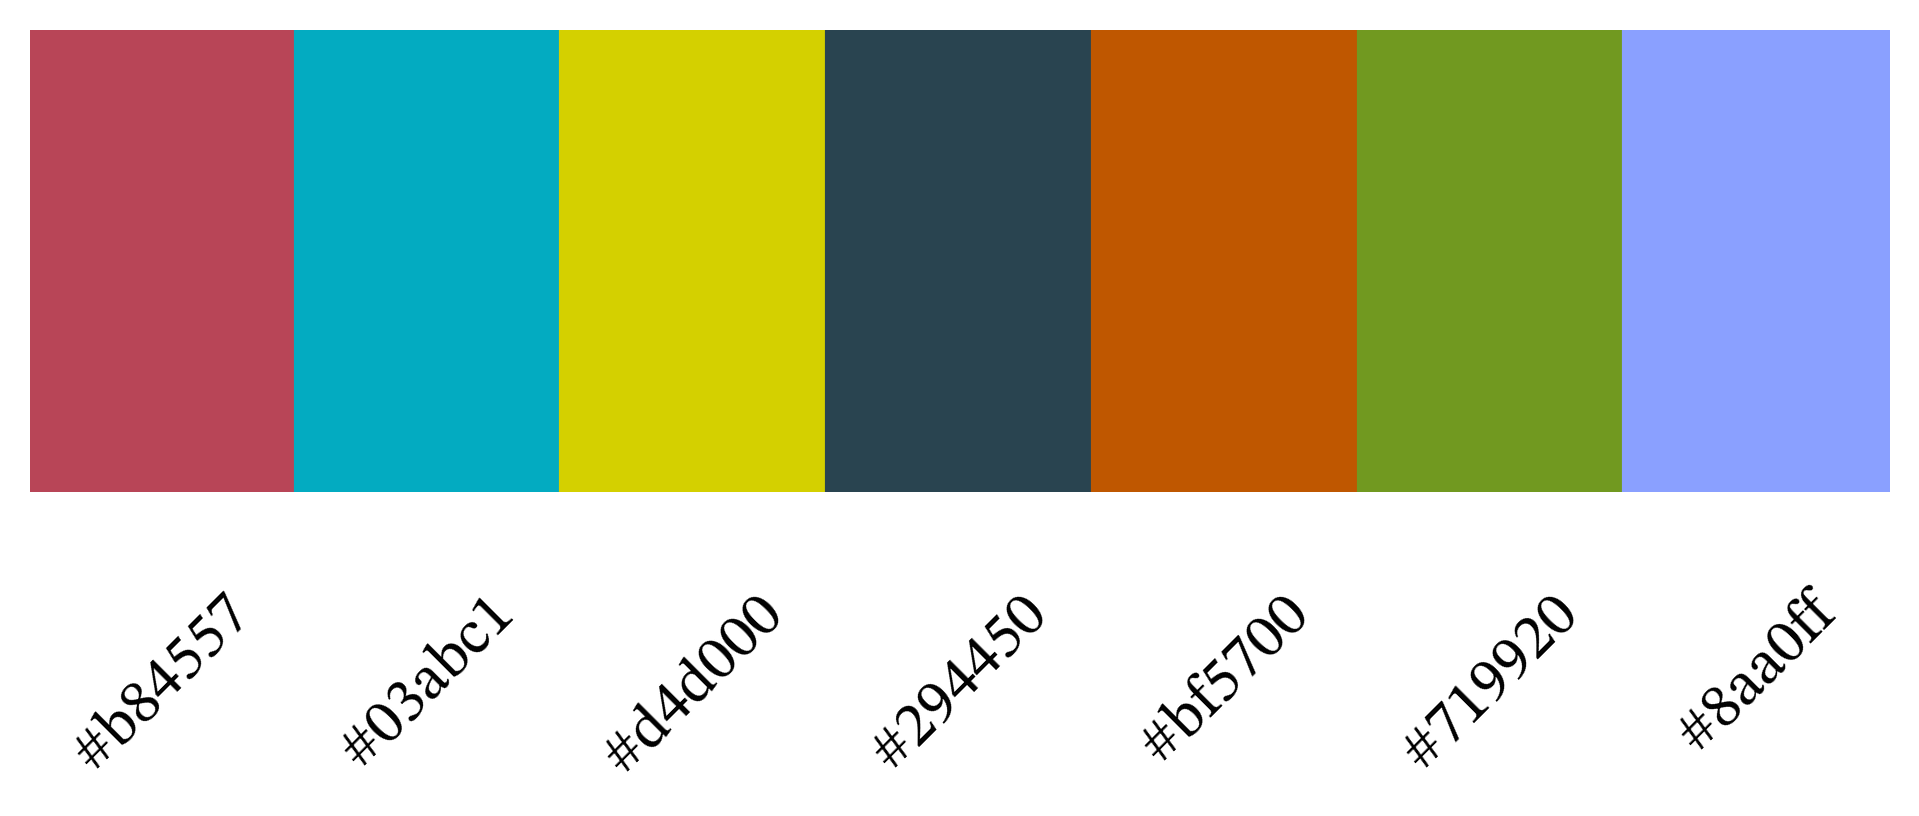

In [28]:
eplots.plot_colors()

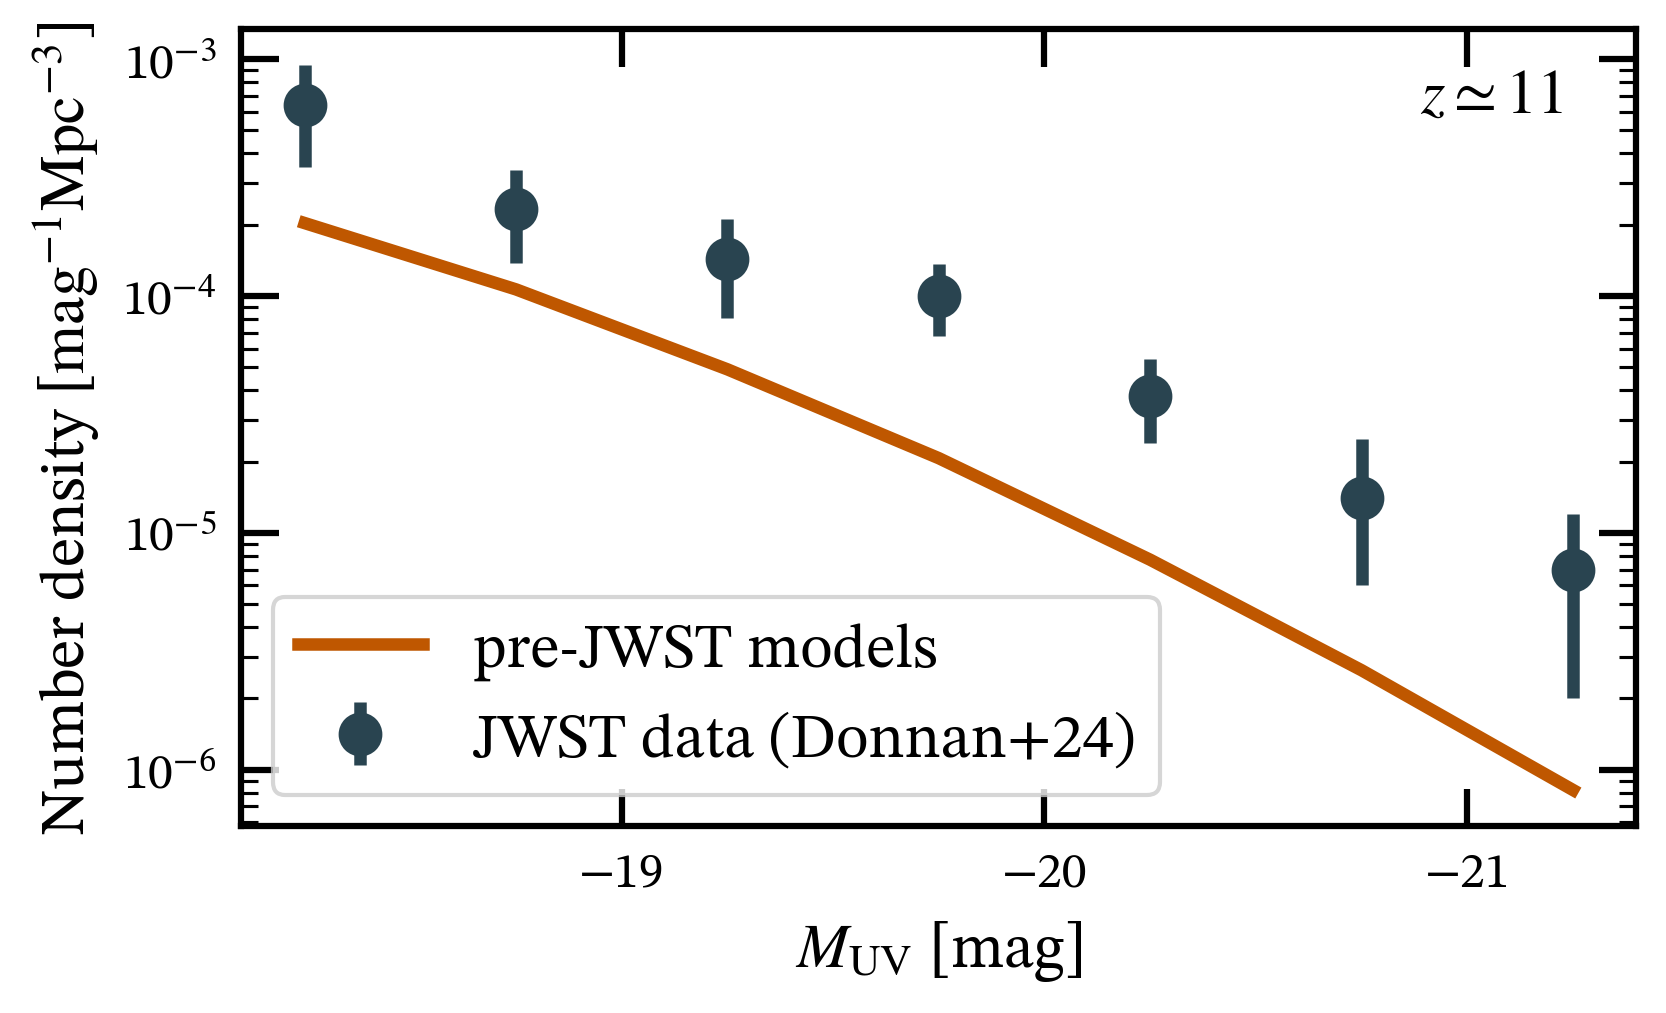

In [ ]:
fig, ax = plt.subplots()
multiple = 1.5
# fig.set_dpi(100)
fig.set_size_inches(multiple*4, multiple*2.3)
plot_xdat, plot_xerr = my_UVLF.data[0][2], my_UVLF.data[0][5]
zdat, zerr = compressed_data[0][0], compressed_data[0][1]
ax.plot(plot_xdat, my_UVLF.UVLF_wrapper(zdat, zerr, plot_xdat, plot_xerr, low_z_fit), label = fr'pre-JWST models', color = eplots.orange)
ax.invert_xaxis()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_ylabel(r'Number density [$\rm{mag}^{-1} \rm{Mpc}^{-3}$]')
ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')

zdat, zerr, xdat, ydat, yerr_upper, yerr_lower, xerr = compressed_data[0]

ax.errorbar(xdat, ydat, yerr=[yerr_lower, yerr_upper],
            capsize=0, label='JWST data (Donnan+24)',
            markeredgecolor=eplots.navy, markeredgewidth=3, fmt='o',
            markerfacecolor=eplots.navy, ecolor=eplots.navy)

ax.legend()
ax.set_yscale('log')
fig.text(.78, .8, r'$z\simeq 11$')

#fig.savefig('/Users/eb35267/Desktop/figures/Committee_25/pre_JWST_comparison.png', bbox_inches='tight')

In [3]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [7]:
params = eMCMC.build_param_data({'beta': {'fit':False, 'value': -0.54}, 'dbetadz': {'fit': False, 'value':0}})
my_UVLF = eMCMC.UVLF(sorted_data, params)
best_fit = [0.87, 0.05, 11.71, 0, -0.98, -0.05, 0.17, 0.17, -0.86, 0.3]

In [139]:
def sfe_shape_diff_z(my_UVLF, param_values, Mhtab, z):

    fig = plt.figure(figsize=(6, 4))
    ax_rect  = [0.10, 0.12, 0.78, 0.80]       # left, bottom, width, height (0-1)
    ax = fig.add_axes(ax_rect)
    
    # Calculate parameters at this z
    params = my_UVLF.time_evolution(param_values, z)
    Astro_Parameters = my_UVLF.param_wrapper(params)
    # Calculate SFE
    SFEs = my_UVLF.CosmoParams.OmegaM/my_UVLF.CosmoParams.OmegaB * zeus21.sfrd.fstarofz(
        Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mhtab)
    ax.axvline(Mhtab[np.where(SFEs == max(SFEs))[0]], color = eplots.navy, lw = 2, ls = 'dashed')
    ax.axhline(max(SFEs)+0.005, color = eplots.navy, ls='dashed', lw = 2)
    plt.plot(Mhtab, SFEs, color = eplots.green, ls = '-', zorder = 0)

    lm_fit, _ = scipy.optimize.curve_fit(f, Mhtab[10:50], SFEs[10:50])
    a, b = lm_fit
    ax.plot(Mhtab[10:50], f(Mhtab[10:50], a + 0.005, b), lw = 2, ls = 'dashed', color = eplots.navy)

    hm_fit, _ = scipy.optimize.curve_fit(f, Mhtab[175:], SFEs[175:])
    a, b = hm_fit
    ax.plot(Mhtab[175:], f(Mhtab[175:], a + 0.005, b), lw = 2, ls = 'dashed', color = eplots.navy)

    # Labels
    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$f_{\star} = \dot M_\star / \dot M_{\rm{gas}}$')
    ax.set_yscale('log')
    
    ax.set_ylim(0.02, 0.2)
        
        
    return fig, ax

def f(x, a, b):
    return 10**((a*x)+b)

Text(9.6, 0.165, '$\\mathbf{\\epsilon}_\\star$')

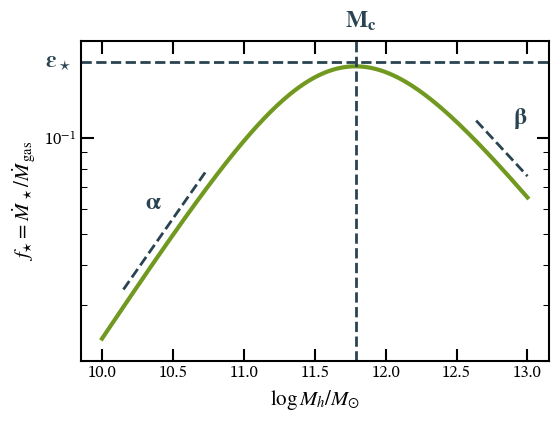

In [140]:
fig, ax = sfe_shape_diff_z(my_UVLF, best_fit, Mhtab = np.linspace(10, 13, 200),
                             z = 4)

ax.text(10.3, 6e-2, r'$\mathbf{\alpha}$', color = eplots.navy)
ax.text(12.9, 1.1e-1, r'$\mathbf{\beta}$', color = eplots.navy)
ax.text(11.71, 2.2e-1, r'$\mathbf{M_c}$', color = eplots.navy)
ax.text(9.6, 1.65e-1, r'$\mathbf{\epsilon}_\star$', color = eplots.navy)

In [141]:
fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/example.png', dpi = 200)

In [ ]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

In [580]:
-0.98+.11

-0.87

In [15]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

In [1]:
fig, ax = eplots.sfe_shape_diff_z(my_UVLF, best_fit, Mhtab = np.linspace(10, 13, 200),
                             zs = np.arange(4, 16, 2))
ax.set_ylabel(r'$f_{\star} = \dot M_\star / \dot M_{\rm{gas}}$', size = 40)
ax.axhline(0.172, ls = 'dashed', color = 'black', lw = 3)
ax.set_ylim(0.01, 0.25)
ax.text(10, 0.185, '$f_\star = 17.2\%$', size = 22)

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_70819/2638013149.py:6: SyntaxWarning: invalid escape sequence '\s'
  ax.text(10, 0.185, '$f_\star = 17.2\%$', size = 22)
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_70819/2638013149.py:6: SyntaxWarning: invalid escape sequence '\s'
  ax.text(10, 0.185, '$f_\star = 17.2\%$', size = 22)


NameError: name 'eplots' is not defined

In [40]:
fig.savefig('/Users/eb35267/Desktop/figures/Committee_25/after_meeting/sfe_high.png', bbox_inches = 'tight')

In [452]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

In [454]:
fig.savefig('/Users/eb35267/Desktop/figures/Committee_25/gaussian.png', bbox_inches='tight')

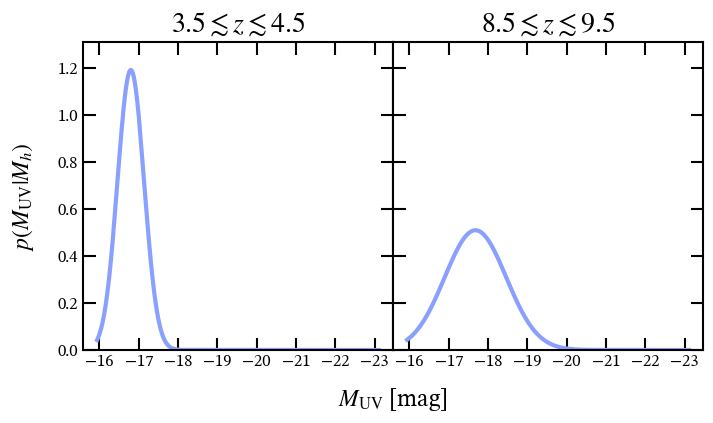

In [113]:
fig, axs = eplots.PMUV(my_UVLF, zs = np.array([4, 9]), Mhtab = np.array([10.5]), 
                                  param_values = best_fit)

In [451]:
fig.savefig('/Users/eb35267/Desktop/figures/Committee_25/gaussian_redshift.png')

In [559]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

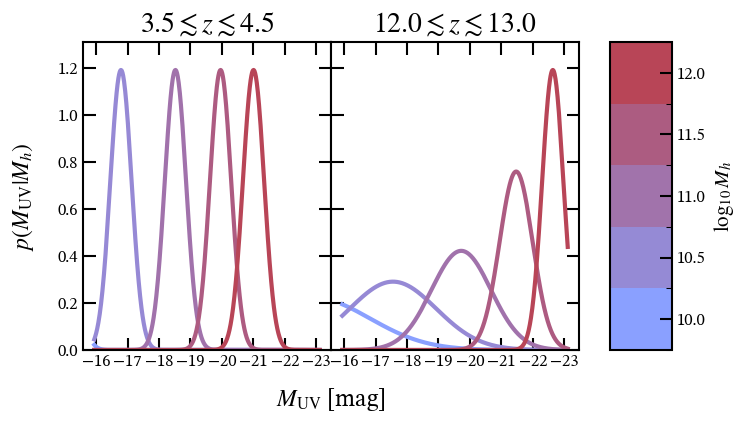

In [118]:
fig, ax = eplots.PMUV(my_UVLF, zs = np.array([4, 12.5]), Mhtab = np.arange(10, 12.5, 0.5), 
                                  param_values = best_fit)

In [127]:
fig.set_size_inches(14, 3)

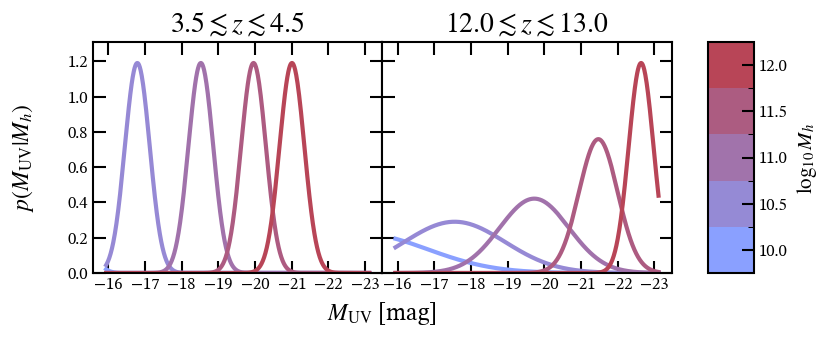

In [128]:
fig

In [129]:
fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/PMUV.png', dpi = 200)

In [9]:
file_name = '/Users/eb35267/Desktop/code/home/figures/remove_weibel_limit_z_fix_beta/zoom_in/samples.h5'

In [528]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

/Users/eb35267/Desktop/code/home/escripts/eplots.py:193: RuntimeWarning: divide by zero encountered in log10
  ax.scatter(xdat, np.log10(ydat), marker = fmt, label = dat[7], c = navy, s = 180)
/Users/eb35267/Desktop/code/home/escripts/eplots.py:193: RuntimeWarning: divide by zero encountered in log10
  ax.scatter(xdat, np.log10(ydat), marker = fmt, label = dat[7], c = navy, s = 180)
/Users/eb35267/Desktop/code/home/escripts/eplots.py:193: RuntimeWarning: invalid value encountered in log10
  ax.scatter(xdat, np.log10(ydat), marker = fmt, label = dat[7], c = navy, s = 180)


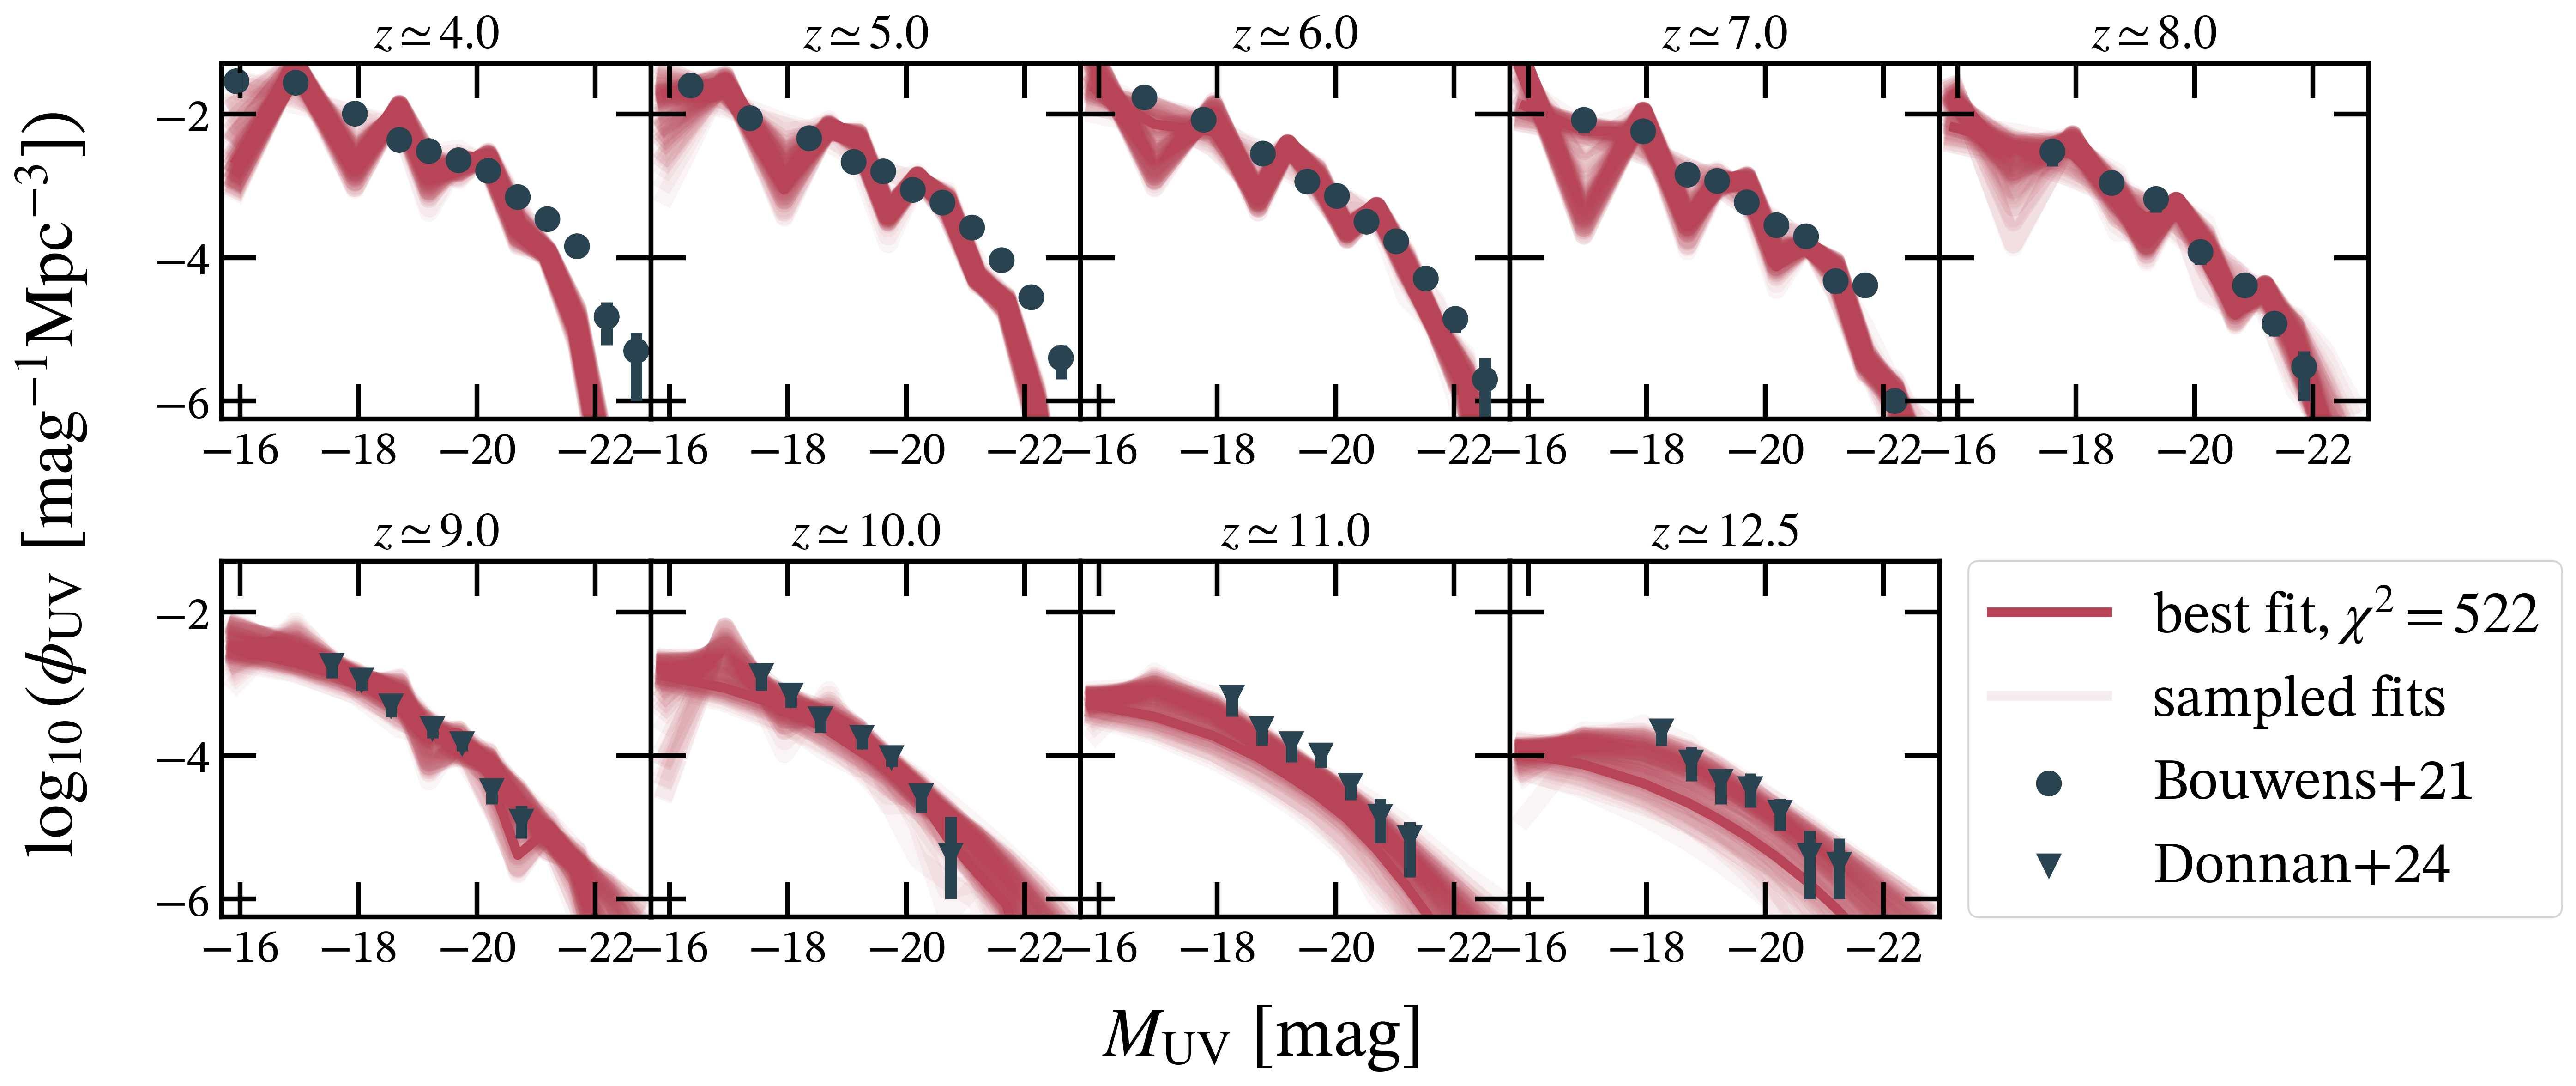

In [565]:
ev_fig = eplots.evolving_UVLF_fit(my_UVLF, backend_file = file_name, title = '', ncols = 5)

In [ ]:
ev_fig.savefig('/Users/eb35267/Desktop/figures/Committee_25/uvlf_fig.png', dpi = 300, bbox_inches = 'tight')

In [536]:
best_fit

[0.87, 0.05, 11.71, 0, -0.98, -0.05, 0.17, 0.17, -0.86]

In [592]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

In [595]:
eMCMC.get_default_df()

,fit,value,lower,upper,label
alpha,True,0.6,0,4,$\alpha$
dalphadz,True,0,-0.5,0.5,$d\alpha/dz$
beta,True,-0.5,-3,0,$\beta$
dbetadz,True,0,-1,1.5,$d\beta/dz$
logMc,True,12,9,16,$\log(M_c)$
dlogMcdz,True,0,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-4.5,0,$\log(\epsilon_0)$
dlogedz,True,0,-0.5,0.5,$d\log(\epsilon_0)/dz$
sig,True,0,0,6,"$\sigma_{\rm{UV}, M_c}$"
dsigdz,True,0,-0.5,1,$d\sigma_{\rm{UV}}/dz$


red: #b84557
turquoise: #03abc1
yellow: #d4d000
navy: #294450
orange: #bf5700
green: #719920
periwinkle: #8aa0ff


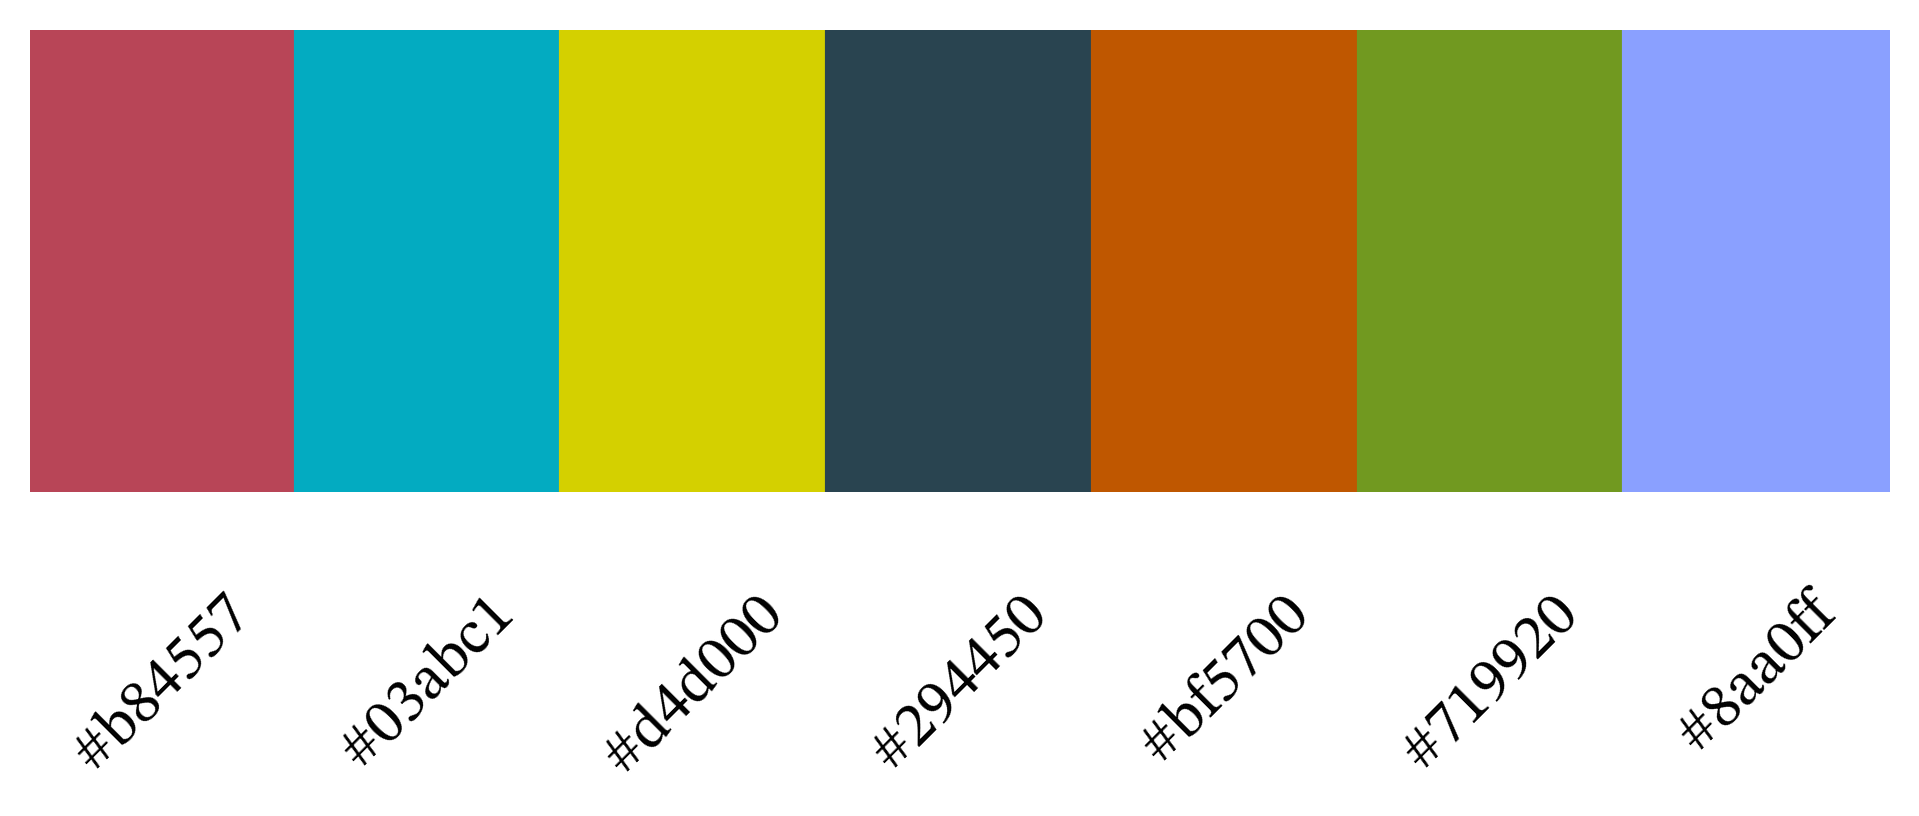

In [598]:
eplots.plot_colors()

In [608]:
importlib.reload(eplots.eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

[-0.87, 0.01]


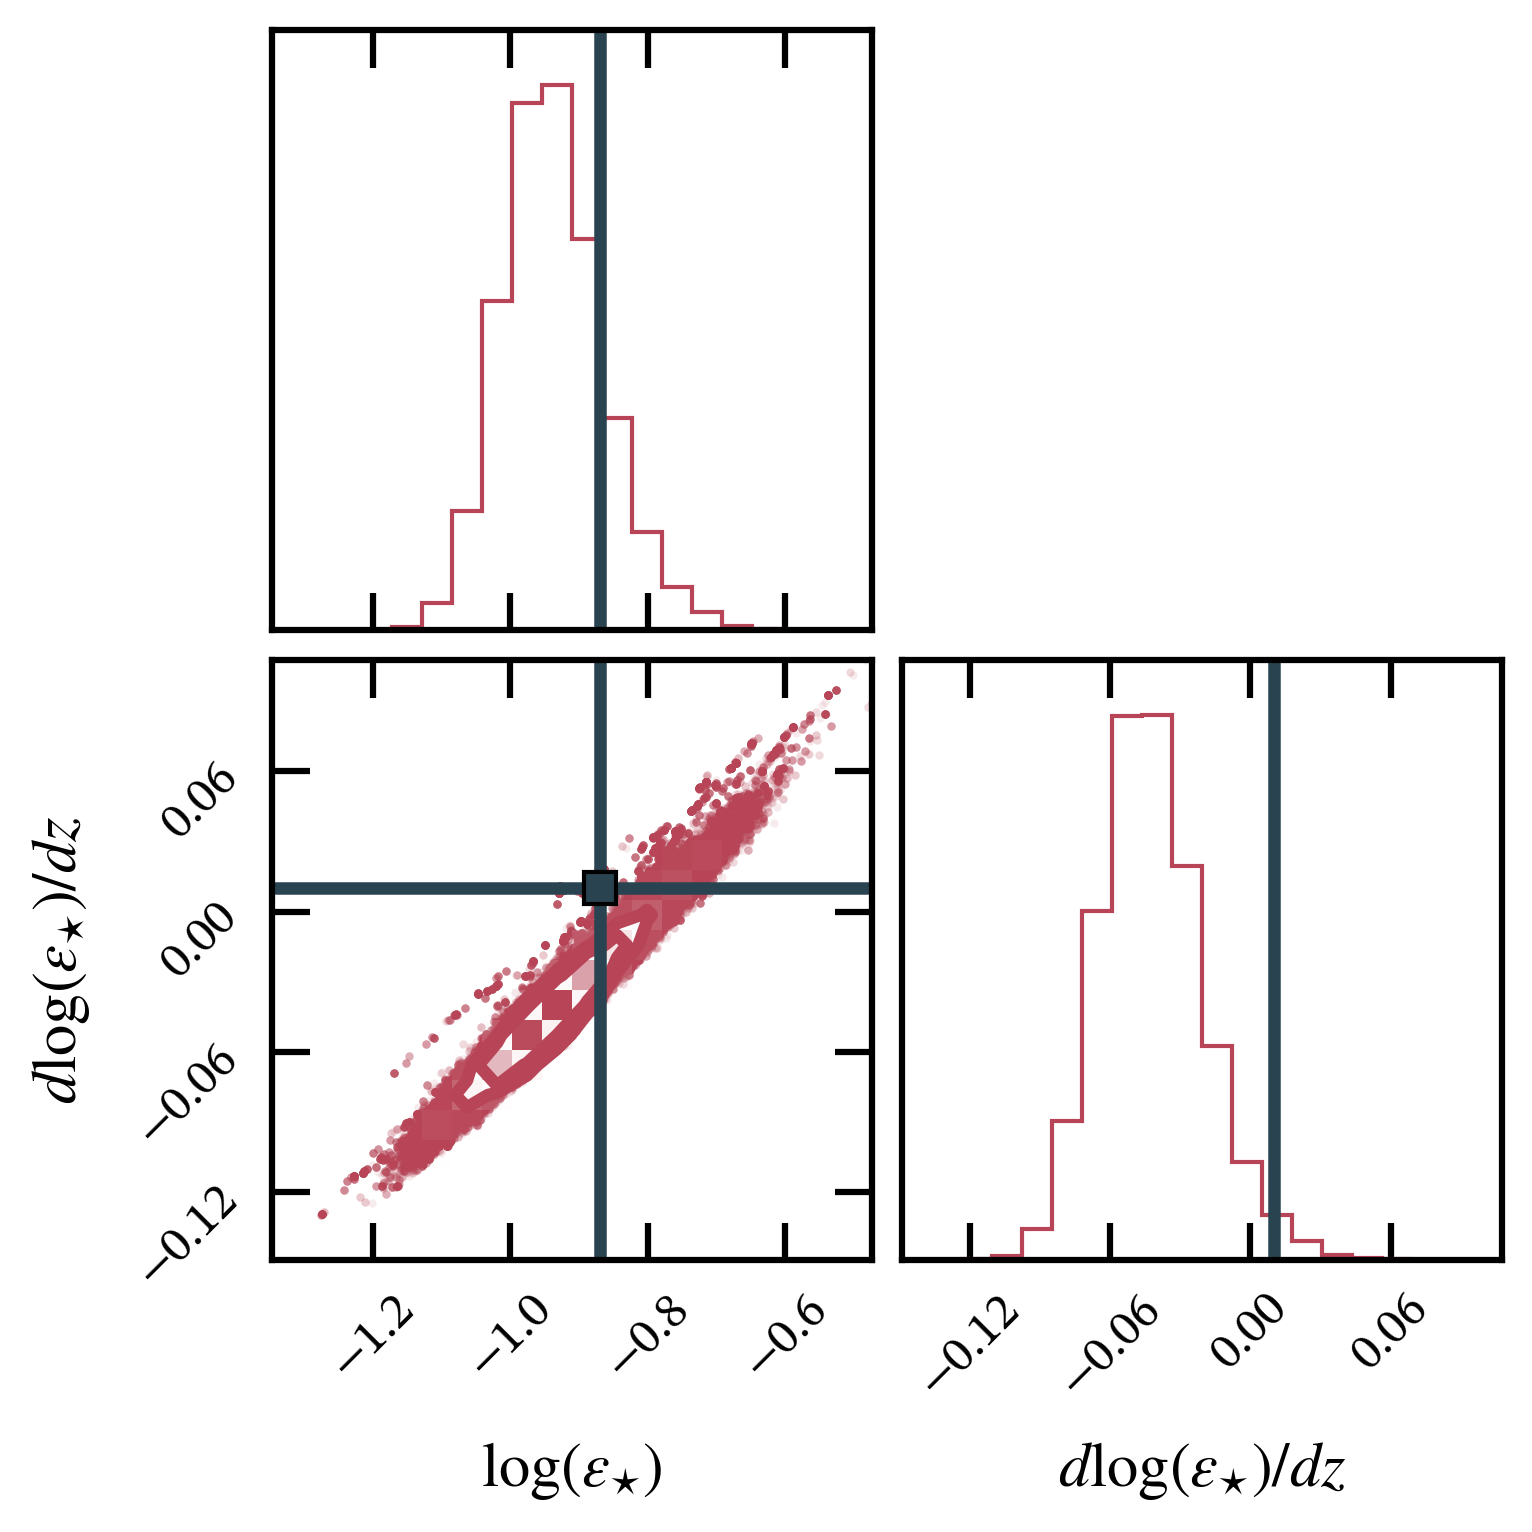

In [41]:
# Corner plot
plt.style.use('/Users/eb35267/Desktop/code/mpl_style/notebook_style.mplstyle')
corner = eplots.make_corner(my_UVLF, backend_file = file_name, excluded_params = ['alpha', 'dalphadz', 'logMc', 'dlogMcdz', 'sig', 'dsigdlogM', 'dsigdz'], 
                             sample_color = eplots.red, truth_color = eplots.navy, true_vals = [-0.87, 0.01])

In [42]:
corner.savefig('/Users/eb35267/Desktop/figures/Committee_25/after_meeting/hypothetical_corner.png', bbox_inches='tight')

In [566]:
FIRE_bursty = np.array([0.21875000000000044, -1.9725675675675678,
0.31250000000000044, -1.4859290540540533,
0.40625000000000044, -1.3236148648648642,
0.5000000000000004, -0.820760135135135,
0.5937500000000004, -0.7557432432432432,
0.7187500000000004, -1.1122972972972978,
0.8125000000000004, -0.7067398648648653,
0.9062500000000004, -0.9336148648648646,
1.0625000000000004, -0.7063344594594598,
1.0937500000000004, -0.4306081081081077,
1.2187500000000004, -0.625,
1.3125000000000004, -0.3816047297297298,
1.40625, -0.39766891891891865,
1.5, -0.31643581081081074,
1.59375, -0.0892567567567566,
1.65625, -0.33239864864864854,
1.71875, -0.5268918918918919,
1.8125, -0.34836148648648635,
1.875, 0.12201013513513503,
1.90625, 0.4788175675675679,
2, -0.12103040540540544,
2.09375, 0.07371621621621616,
2.1875, 0.1549493243243245,
2.3125, 0.39839527027027,
2.40625, 0.17152027027027028,
2.5, 0.6095101351351357,
2.59375, 0.7393918918918923,
2.6875, -0.39559121621621607,
2.8125, 0.3181250000000002,
2.90625, 0.13989864864864865,
3.03125, 0.25361486486486484,
3.09375, 0.38344594594594605,
3.21875, 0.23770270270270233,
3.3125, 0.7243412162162164,
3.40625, 0.059628378378378866,
3.5, 0.17329391891891888,
3.59375, 0.38425675675675697,
3.71875, 0.15743243243243255,
3.8125, 0.2873141891891895,
3.875, 0.3522804054054056,
4, 0.38491554054054067,
4.09375, 0.36885135135135094,
4.21875, 0.40148648648648644,
4.3125, 0.7259628378378378,
4.5, 0.09383445945946,
4.59375, 0.4669594594594595,
4.71875, 0.48337837837837894,
4.78125, 0.48347972972972997,
4.90625, 0.9863851351351354,
5, 0.09464527027027048,
5.09375, 0.7758783783783789,
5.187499999999999, 0.3057601351351349,
5.312499999999999, 0.8735304054054058,
5.406249999999999, -0.09929054054054065,
5.499999999999999, 0.6630236486486489,
5.593749999999999, -0.2935810810810806,
5.812499999999999, 0.5662331081081082,
5.906249999999999, 0.6798986486486487,
5.999999999999999, -0.09832770270270252,
6.093749999999999, 0.5180405405405404,
6.218749999999999, 0.5668918918918919,
6.312499999999999, 0.9238006756756758,
6.406249999999999, 0.5023310810810808,
6.499999999999999, 0.6159966216216222,
6.593749999999999, 0.22695945945945972,
6.687499999999999, 0.4703547297297299,
6.781249999999999, 0.4218581081081081,
6.906249999999999, 0.40584459459459454,
6.968749999999999, 0.7140540540540541,
7.093749999999999, 0.7629054054054056,
7.187499999999999, 0.3252195945945946,
7.281249999999999, 0.6496959459459464,
7.406249999999999, 0.3093581081081078,
7.499999999999999, 0.877077702702703,
7.593749999999999, 0.06641891891891927,
7.687499999999999, 0.601706081081081,
7.812499999999999, 0.4559628378378382,
7.968749999999999, 0.9102702702702707,
8.09375, 0.16452702702702693,
8.21875, 0.9917567567567569,
8.281249999999996, 0.3107770270270267,
8.406249999999996, 0.31097972972972965,
8.5, 0.6841047297297296,
8.59375, 0.4247972972972973,
8.6875, 0.6033277027027029,
8.781249999999996, 0.7332094594594594,
8.906249999999996, 0.4577364864864868,
9, 0.5551858108108108,
9.09375, 0.7499324324324328,
9.1875, 1.009543918918919,
9.281249999999996, 0.620506756756757,
9.406249999999996, 0.5071959459459454,
9.5, 0.8154560810810811,
9.59375, 0.6534459459459465,
9.6875, 0.9779222972972974,
9.781249999999996, 0.5888851351351354,
9.906249999999996, 0.670168918918919,
10, 0.24869932432432407,
10.0625, 0.6866385135135133,
10.09375, 0.9461486486486486,
10.281249999999996, 0.3140202702702699,
10.406249999999996, 0.7520608108108111,
10.5, 0.6549155405405407,
10.59375, 0.7361486486486486,
10.6875, 0.42819256756756774,
10.781249999999996, 0.8337500000000002,
10.875, 0.7366047297297298,
11, 0.7530236486486488,
11.09375, 0.8018243243243246,
11.1875, 0.6884628378378377,
11.281249999999996, 0.8183445945945946,
11.375, 0.8347128378378379,
11.46875, 0.77,
11.59375, 0.7702027027027025,
11.6875, 0.8514358108108109,
11.781249999999996, 0.7380743243243244,
11.906249999999996, 0.7707094594594595,
11.96875, 0.8518918918918921,
12.125, 0.7872804054054057,
12.1875, 0.8035979729729732,
12.3125, 0.7713682432432432,
12.4375, 0.7715709459459461,
12.59375, 0.8042567567567569,
12.6875, 0.7557601351351355,
12.781249999999996, 0.7883445945945948,
12.874999999999996, 0.7560641891891895,
13.062499999999996, 0.740152027027027,
13.187499999999996, 0.772787162162162,
13.312499999999996, 0.7243412162162164,
13.406249999999996, 0.6758445945945946,
13.437499999999996, 0.7083277027027028]).reshape(-1,2)

Illustris = np.array([0.3335033146353905, -1.9729729729729728,
0.36681964983851856, -1.794594594594595,
0.46591874893761753, -1.3405405405405402,
0.49957504674485875, -1.1297297297297293,
0.5962944076151633, -0.9027027027027028,
0.6612272650008508, -0.7081081081081084,
0.9167091619921814, -0.33513513513513526,
1.1069182389937113, -0.18918918918918948,
1.518612952575217, 0.08648648648648649,
2.118816930137685, 0.34594594594594597,
2.2447730749617545, 0.362162162162162,
2.3081761006289305, 0.4108108108108106,
2.9070202277749457, 0.5405405405405403,
3.2218255991840907, 0.5729729729729729,
3.410674825769166, 0.5891891891891889,
3.6624171341152483, 0.6054054054054054,
3.8512663607003237, 0.6216216216216215,
3.9144994050654436, 0.654054054054054,
4.008499065102838, 0.6216216216216215,
4.102838687744349, 0.6216216216216215,
4.197348291687915, 0.6378378378378375,
4.323134455209927, 0.6378378378378375,
4.669046404895463, 0.6378378378378375,
4.889172191058984, 0.6378378378378375,
5.172191058983513, 0.6378378378378375,
5.423763386027537, 0.6378378378378375,
5.612612612612613, 0.654054054054054,
5.832568417474079, 0.6378378378378375,
5.927078021417644, 0.654054054054054,
6.021247662757098, 0.6378378378378375,
6.115757266700664, 0.654054054054054,
6.209926908040117, 0.6378378378378375,
6.335883052864185, 0.654054054054054,
6.870134285228625, 0.6216216216216215,
7.058813530511644, 0.6216216216216215,
7.341662417134117, 0.6054054054054054,
7.436172021077681, 0.6216216216216215,
7.530341662417134, 0.6054054054054054,
7.687744348121706, 0.6216216216216215,
7.8135305116437195, 0.6216216216216215,
7.907870134285227, 0.6216216216216215,
8.065102838687745, 0.6216216216216215,
8.159272480027196, 0.6054054054054054,
8.28505864354921, 0.6054054054054054,
8.379568247492776, 0.6216216216216215,
8.505184429712733, 0.6054054054054054,
8.6311405745368, 0.6216216216216215,
8.725310215876254, 0.6054054054054054,
8.88254292027877, 0.6054054054054054,
9.102498725140237, 0.5891891891891889,
9.385517593064764, 0.5891891891891889,
9.7314295427503, 0.5891891891891889,
10.171851096379399, 0.6054054054054054,
10.234404215536292, 0.5729729729729729,
10.29763725990141, 0.6054054054054054,
10.454530001699814, 0.5729729729729729,
10.674655787863335, 0.5729729729729729,
10.863505014448412, 0.5891891891891889,
10.989121196668368, 0.5729729729729729,
11.11490736019038, 0.5729729729729729,
11.30341662417134, 0.5567567567567564,
11.554988951215366, 0.5567567567567564,
11.64915859255482, 0.5405405405405403,
11.743668196498387, 0.5567567567567564,
11.837837837837839, 0.5405405405405403,
12.278089410164881, 0.5405405405405403,
12.498215196328404, 0.5405405405405403,
12.718340982491927, 0.5405405405405403,
12.875403705592387, 0.5243243243243239,
13.22131565527792, 0.5243243243243239,
13.283868774434811, 0.4918918918918913,
13.31565527791943, 0.5243243243243239,
13.598334183239842, 0.4918918918918913]).reshape(-1,2)

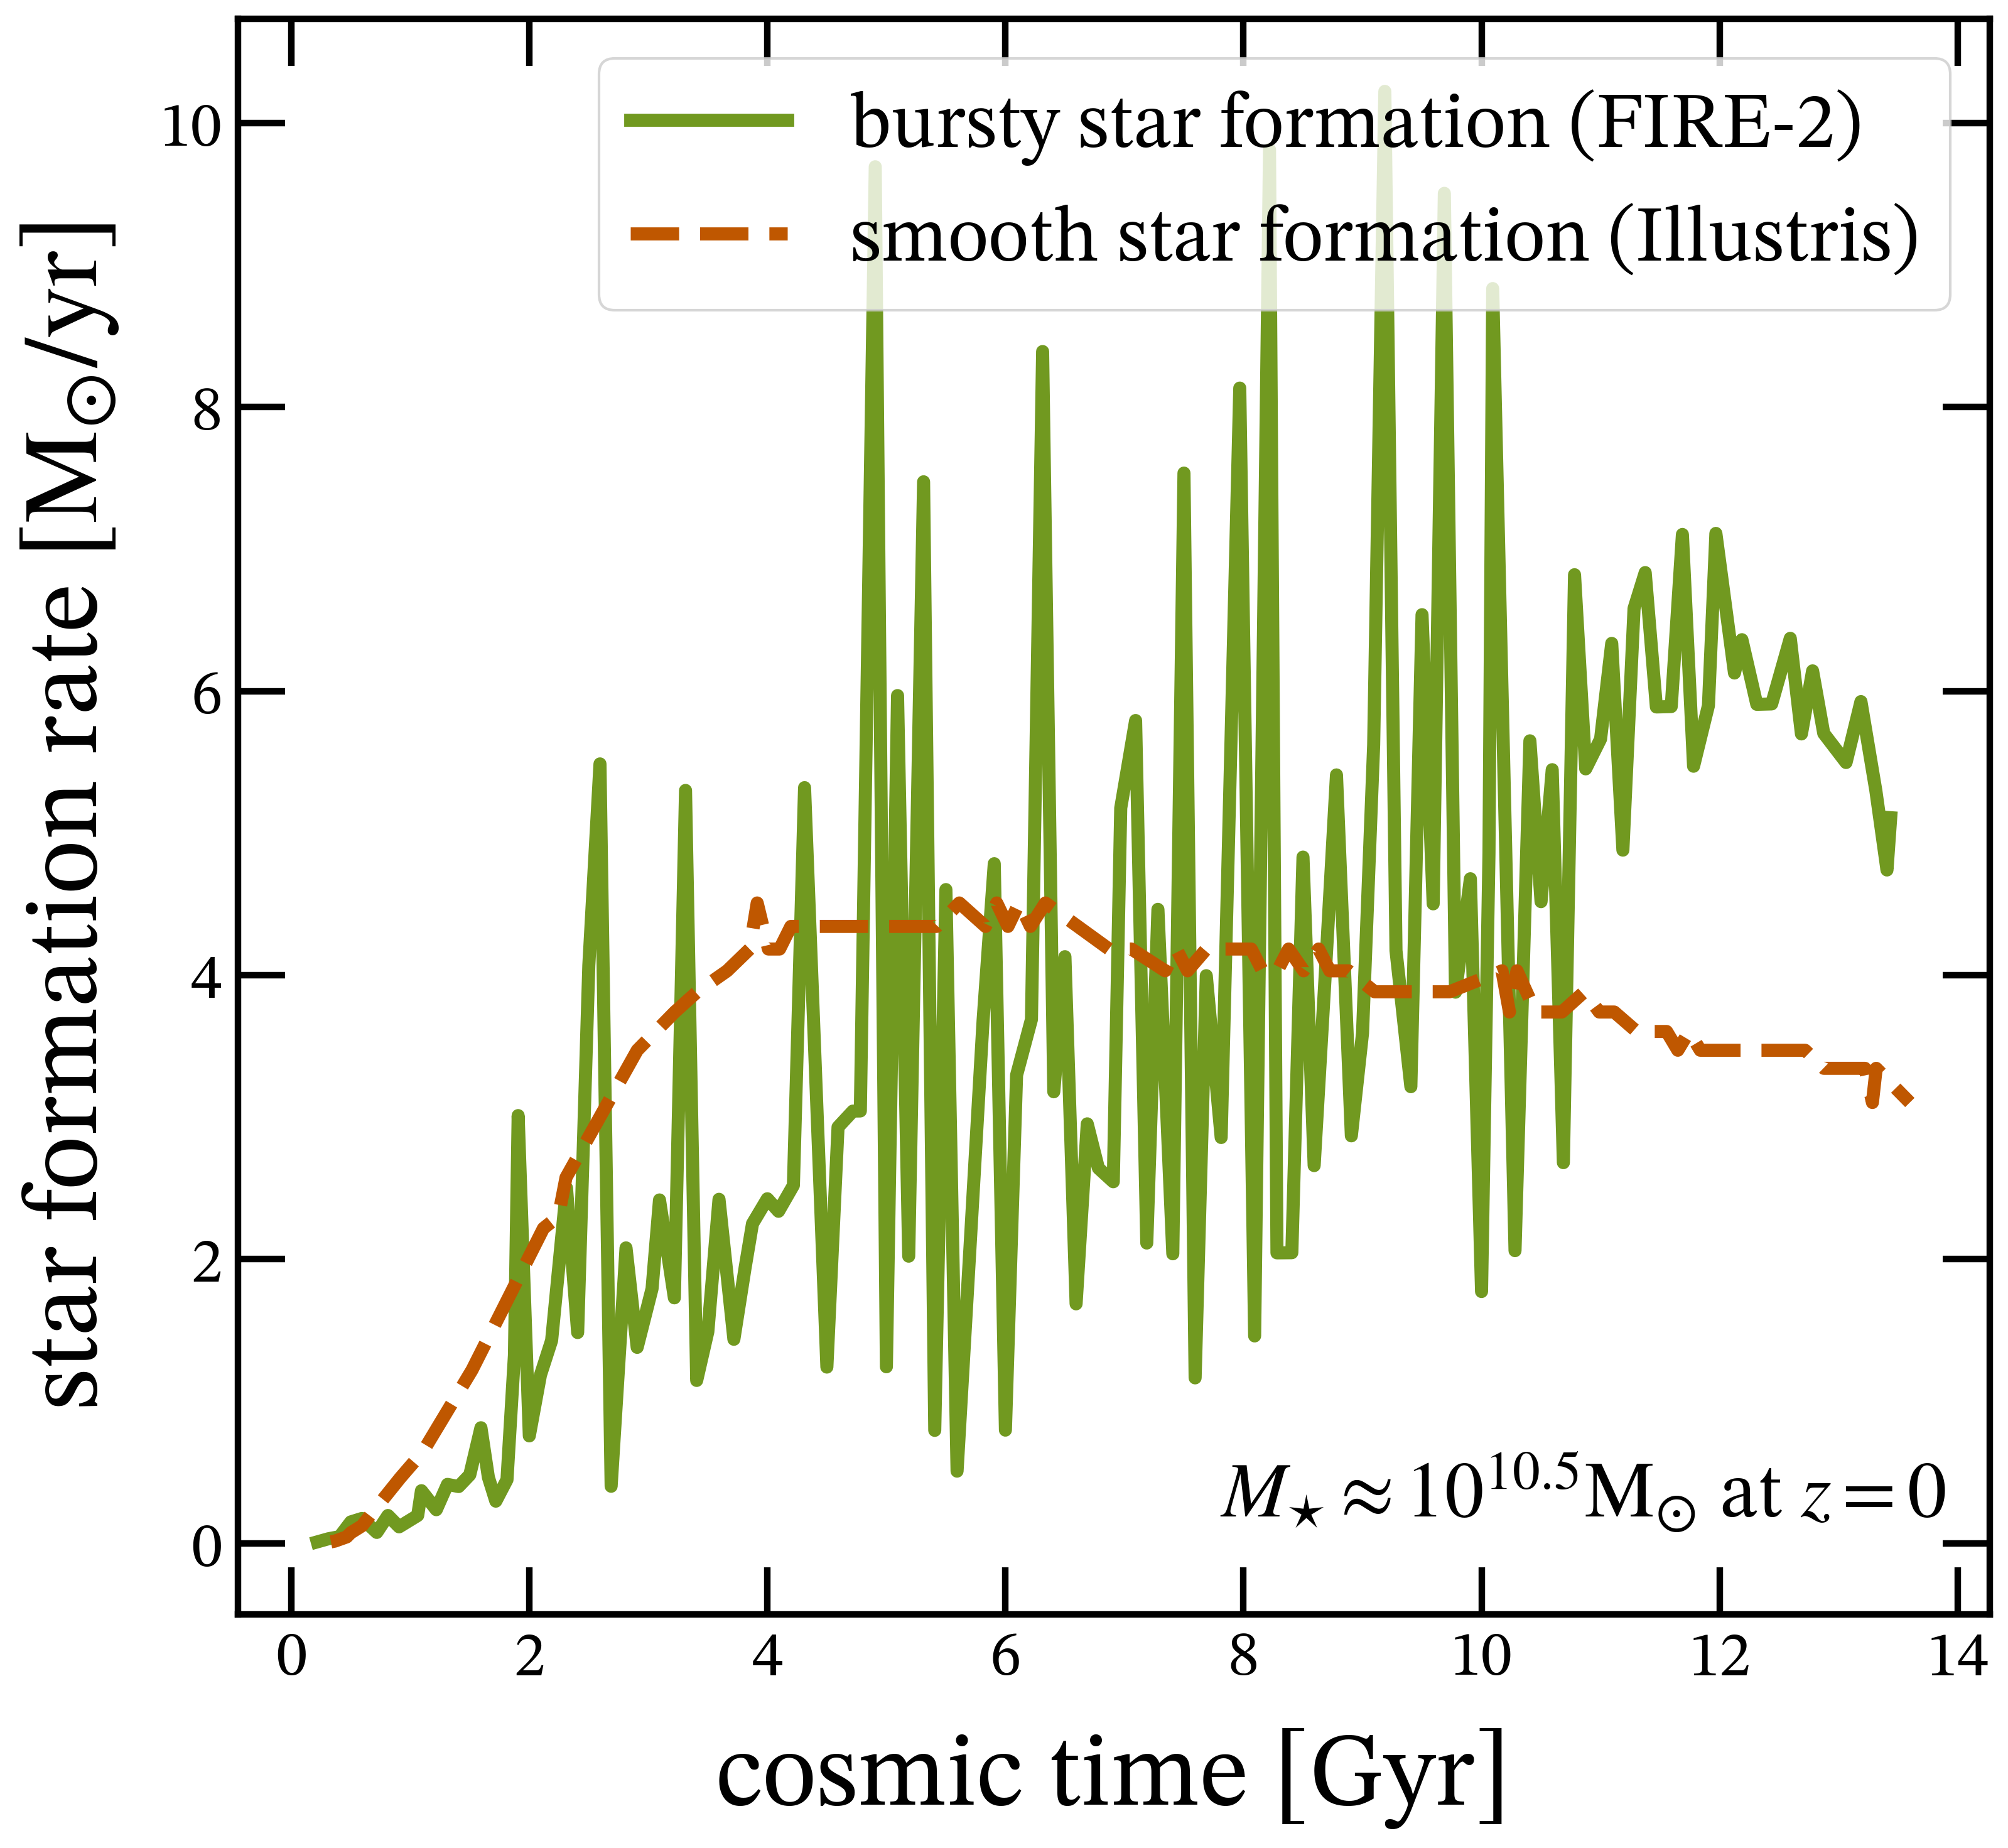

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 11)
ax.plot(FIRE_bursty[:,0], 10**FIRE_bursty[:,1], label = 'bursty star formation (FIRE-2)', color = eplots.green, 
        lw = 5)
ax.plot(Illustris[:,0], 10**Illustris[:,1], label = 'smooth star formation (Illustris)', color = '#bf5700', 
        lw = 5)
ax.legend()
ax.set_ylabel(r'star formation rate [$\rm{M}_{\odot} / \rm{yr}$]')
ax.set_xlabel('cosmic time [Gyr]')
plt.text(0.975, 0.05, r'$M_{\star} \approx 10^{10.5}\rm{M}_{\odot}$ at $z = 0$', transform=plt.gca().transAxes, verticalalignment='bottom', 
         horizontalalignment='right')

#fig.savefig('/Users/eb35267/Desktop/figures/Committee_25/bursty_Iyer.png', bbox_inches = 'tight')